In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from tqdm import tqdm

# Set up a PSD wavefront error

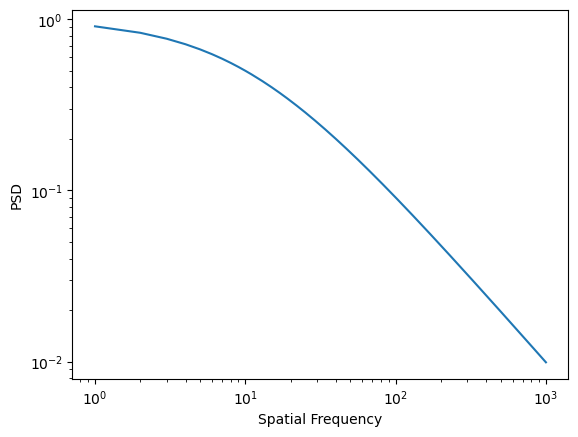

In [2]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()


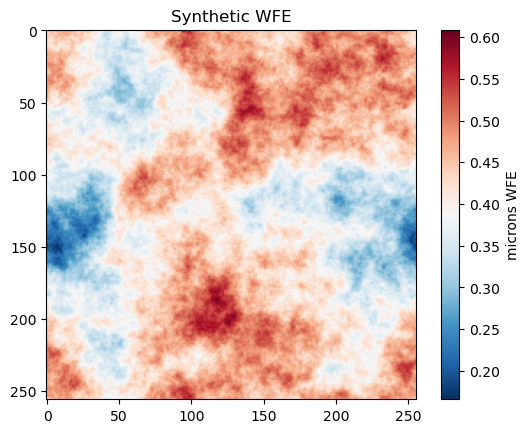

In [3]:
# Just picked ABC values until it looked about right
Npup = 256
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

# 2. Set up a diffraction model

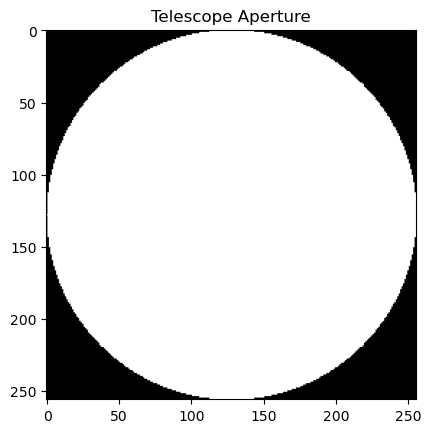

In [4]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
plt.figure()
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.show()

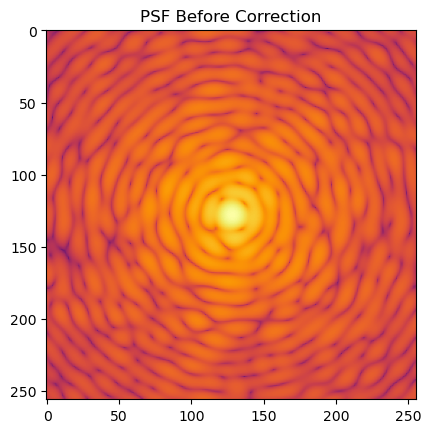

In [5]:
# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

focal_intensity = np.abs(focal)**2

plt.title('PSF Before Correction')
plt.imshow(focal_intensity, cmap='inferno', norm=LogNorm())

# Now in principle, I think iEFC works in direct-imaging mode

0.1


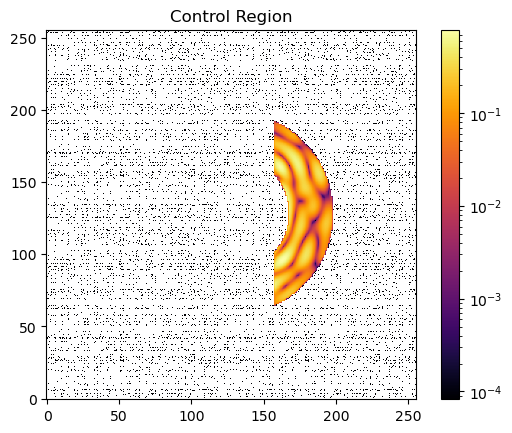

In [6]:
# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
print(um_to_LD)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
dark_hole[rho < 7] = 1
dark_hole[rho < 4] = 0
dark_hole[u < 3] = 0

masked_intensity = dark_hole * focal_intensity
plt.title('Control Region')
plt.imshow(masked_intensity, cmap='inferno', norm=LogNorm(), origin='lower')

plt.colorbar()

# Configure Deformable Mirror with Modes

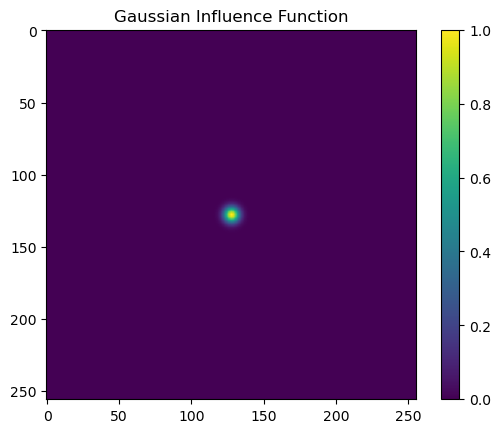

In [7]:
# Set up DM
nact = 34 # number of actuators
act_pitch = 1 # mm?
samples_per_act = 7 # chosen to over-fill illuminated aperture
sampling_pitch = act_pitch / samples_per_act

xdm, ydm = make_xy_grid(Npup, dx=sampling_pitch)
rhodm, _ = cart_to_polar(xdm, ydm)
influence_func = gaussian_influence_function(rho, sampling_pitch)

plt.title("Gaussian Influence Function")
plt.imshow(influence_func)
plt.colorbar()
plt.show()

In [8]:
dm = DM(influence_func, Nout=Npup, Nact=nact, sep=samples_per_act)

# Generate a random modal basis

In [9]:
from poi.modes import hadamard_modes_sequence

xact, yact = make_xy_grid(nact, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

modes = hadamard_modes_sequence(circ_dm_mask)
print(f"Num Modes = {modes.shape[0]}")

Num Modes = 2048


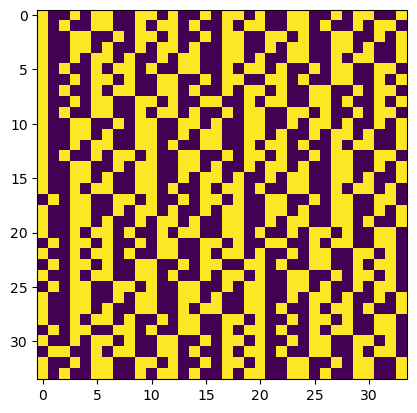

In [10]:
plt.imshow(modes[-1])

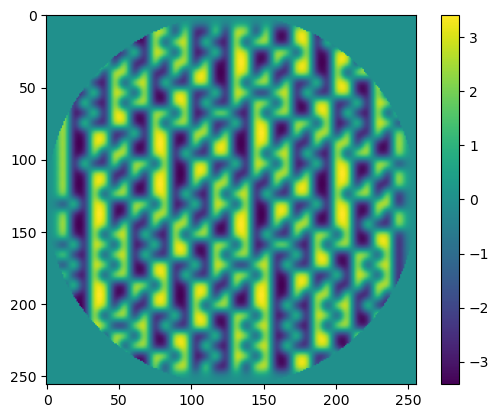

In [11]:
dm.actuators[:] = modes[-1]
plt.imshow(dm.render() * A)
plt.colorbar()

In [12]:
def fwd(pupil_wfe=np.ones_like(wvfnt)):
    focal = focus_fixed_sampling(wvfnt * pupil_wfe,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    return focal

In [ ]:
class iEFC:

    def __init__(self, propagation, dm, modes, dh):

        self.fwd = propagation
        self.dm = dm
        self.modes = modes
        self.dh = dh

    def take_measurement()

# Generate Response Matrix

In [69]:
response_matrix = []
command_amplitude = 1/25
for mode in tqdm(modes):

    # plus image
    dm.actuators[:] = mode * command_amplitude
    wfe_p = np.exp(1j * 2 * np.pi / WVL * dm.render(wfe=True))
    wfe_m = np.exp(1j * 2 * np.pi / WVL * -dm.render(wfe=True))
    focal_intensity_p1 = np.abs(fwd(pupil_wfe=wfe_p))**2
    focal_intensity_p2 = np.abs(fwd(pupil_wfe=wfe_m))**2

    # minus image
    dm.actuators[:] = -mode * command_amplitude
    wfe_p = np.exp(1j * 2 * np.pi / WVL * dm.render(wfe=True))
    wfe_m = np.exp(1j * 2 * np.pi / WVL * -dm.render(wfe=True))
    focal_intensity_n1 = np.abs(fwd(pupil_wfe=wfe_p))**2
    focal_intensity_n2 = np.abs(fwd(pupil_wfe=wfe_m))**2

    # double difference
    focal_intensity_p = (focal_intensity_p1 - focal_intensity_p2) / (2 * command_amplitude)
    focal_intensity_m = (focal_intensity_n1 - focal_intensity_n2) / (2 * command_amplitude)

    # image difference
    dimg = (focal_intensity_p - focal_intensity_m) / (2 * command_amplitude)
    dimg_dh = dimg[dark_hole==1]
    response_matrix.append(dimg_dh)

100%|██████████| 2048/2048 [00:45<00:00, 44.82it/s]


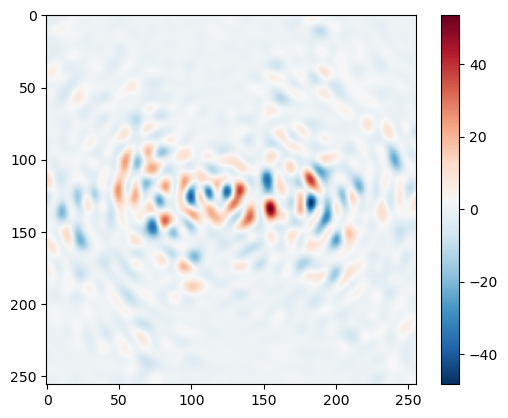

In [70]:
plt.imshow(focal_intensity_p - focal_intensity_m, cmap="RdBu_r")
plt.colorbar()

In [71]:
control_matrix = np.linalg.pinv(response_matrix)

In [77]:
MAX_ITER = 100
intermediate_psfs = []
mean_in_dh = []
for i in tqdm(range(MAX_ITER)):
    if i == 0:
        pix_in_dh = np.abs(fwd())**2
        pix_in_dh = pix_in_dh[dark_hole==1]
        dm_solutions = pix_in_dh @ control_matrix
        dm.actuators[:] = np.sum(modes * dm_solutions[..., None, None], axis=0) * command_amplitude
        wfe = np.exp(1j * 2 * np.pi / WVL * dm.render(wfe=True)) * A
        after_wfsc = np.abs(fwd(pupil_wfe=wfe))**2
        intermediate_psfs.append(after_wfsc)
        pix_in_dh = after_wfsc[dark_hole==1]
        mean_in_dh.append(np.mean(pix_in_dh))

    else:
        dm_solutions = pix_in_dh @ control_matrix
        dm.actuators[:] = np.sum(modes * dm_solutions[..., None, None], axis=0) * command_amplitude
        wfe = np.exp(1j * 2 * np.pi / WVL * dm.render(wfe=True)) * A
        after_wfsc = np.abs(fwd(pupil_wfe=wfe))**2
        intermediate_psfs.append(after_wfsc)
        pix_in_dh = after_wfsc[dark_hole==1]
        mean_in_dh.append(np.mean(pix_in_dh))


100%|██████████| 100/100 [00:01<00:00, 66.23it/s]


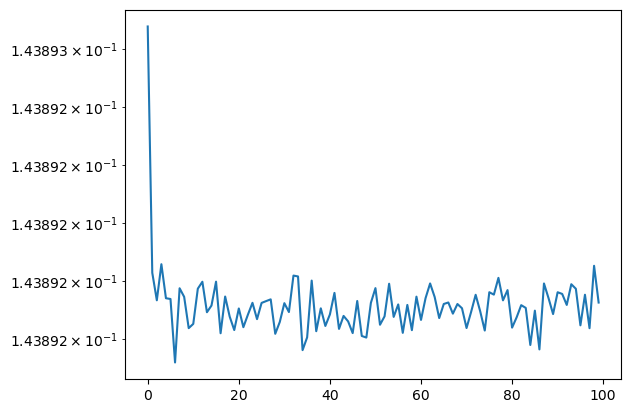

In [78]:
plt.plot(mean_in_dh)
plt.yscale("log")

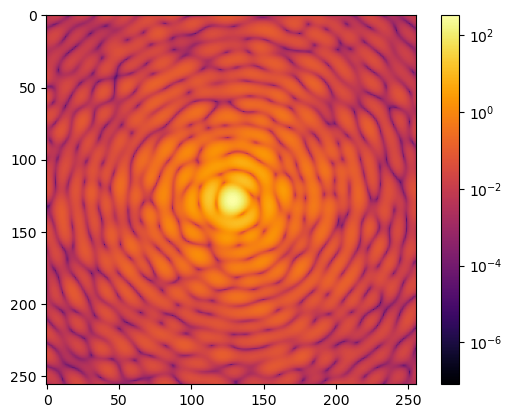

In [79]:
plt.imshow(intermediate_psfs[-1] , cmap="inferno", norm=LogNorm())
plt.colorbar()

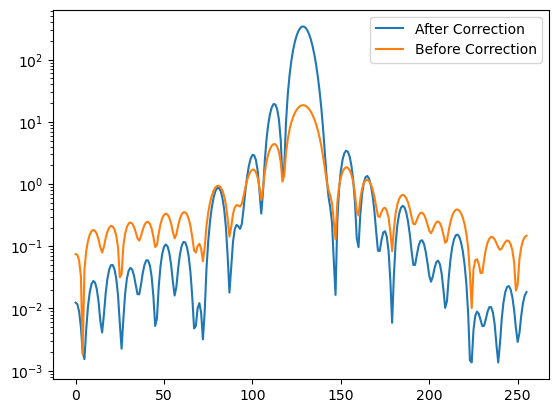

In [75]:
plt.plot(np.abs(after_wfsc[128,:]), label="After Correction")
plt.plot(np.abs(fwd()[128,:]), label="Before Correction")
plt.yscale("log")
plt.legend()

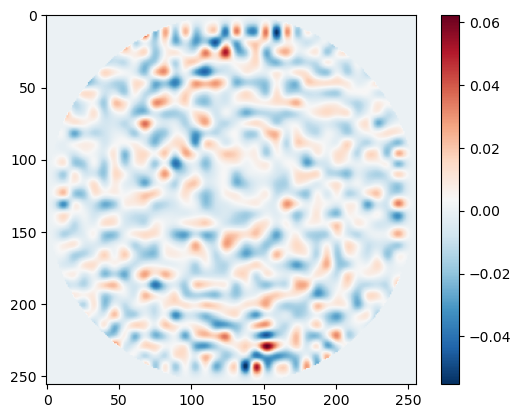

In [76]:
plt.imshow(dm.render(wfe=True) * A, cmap="RdBu_r")
plt.colorbar()